In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

# Seção 1 – Definição do Objetivo

## 1.1 Objetivo da pesquisa

O objetivo deste projeto é avaliar o desempenho esperado de um método de classificação supervisionada para prever se um cliente irá subscrever um depósito a prazo durante uma campanha de marketing telefônico de um banco português.

Problema de classificação binária: dado o conjunto de características socioeconômicas do cliente e informações sobre o contato telefônico, classificar a variável-alvo **y** em:

- **yes**: cliente subscreveu o depósito
- **no**: cliente não subscreveu

O estudo busca obter a distribuição do desempenho do modelo em dados vistos (treino) e não vistos (teste), utilizando um método de reamostragem repetida, sem ajuste de hiperparâmetros baseado nos dados.


## 1.2 Fatores considerados e variáveis correspondentes

### A. Dados do cliente

- `age`
- `job`
- `marital`
- `education`
- `default`
- `balance`
- `housing`
- `loan`

### B. Informações do último contato da campanha

- `contact`
- `day`
- `month`
- `duration`

### C. Histórico de campanhas anteriores

- `campaign`
- `pdays`
- `previous`
- `poutcome`

## 1.3 Variável-alvo e variáveis independentes

- **Variável-alvo (dependente)**  
  - `y`: indica se o cliente subscreveu um depósito a prazo (`yes`/`no`)

- **Variáveis independentes (preditoras)**  
  - Todas as demais 16 variáveis listadas nas seções A, B e C

In [3]:
# Shape, colunas e primeiras linhas

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

print("\nColunas do dataset:")
print(X.columns.tolist())

print("\n5 primeiras linhas:")
display(X.head())

Formato de X: (45211, 16)
Formato de y: (45211, 1)

Colunas do dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

5 primeiras linhas:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [4]:
# Tipos de dados
print("\nTipos de dados das variáveis:")
print(X.dtypes)


Tipos de dados das variáveis:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
dtype: object


In [5]:
# Distribuição da variável-alvo
print("\nDistribuição da variável-alvo (contagem):")
print(y['y'].value_counts())

print("\nDistribuição relativa (proporções):")
print(y['y'].value_counts(normalize=True))


Distribuição da variável-alvo (contagem):
y
no     39922
yes     5289
Name: count, dtype: int64

Distribuição relativa (proporções):
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


In [6]:
# Valores ausentes
print("\nValores ausentes em cada variável:")
print(X.isna().sum())


Valores ausentes em cada variável:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64


# Seção 2 – Caracterização da Base

A base utilizada neste projeto é o conjunto de dados **Bank Marketing** (UCI id=222), composto por **45.211 instâncias** e **16 variáveis preditoras**, além de uma variável-alvo binária. O objetivo da base é registrar características de clientes de um banco português e informações de campanhas telefônicas realizadas para oferta de depósitos a prazo.

## 2.1 Estrutura geral e tipos de dados

O dataset possui **16 variáveis independentes**, distribuídas da seguinte forma:

- **Numéricas (int64):**
  - `age`, `balance`, `day_of_week`, `duration`, `campaign`, `pdays`, `previous`

- **Categóricas (object):**
  - `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`

No total, o conjunto contém variáveis:
- demográficas (`age`, `job`, `marital`, `education`)
- financeiras (`balance`, `housing`, `loan`, `default`)
- referentes ao contato da campanha (`contact`, `day_of_week`, `month`, `duration`)
- histórico de interações anteriores (`campaign`, `pdays`, `previous`, `poutcome`)

A variável-alvo **y** contém os valores “yes” e “no”, indicando se o cliente realizou ou não o depósito a prazo ofertado.

## 2.2 Distribuição da variável-alvo

A distribuição observada no conjunto é fortemente desbalanceada:

- **no:** 39.922 instâncias (≈ **88,30%**)  
- **yes:** 5.289 instâncias (≈ **11,69%**)

Esse desbalanceamento tem impacto direto tanto na estratégia de avaliação quanto na escolha das métricas, já que a acurácia tende a favorecer o acerto da classe majoritária.

## 2.3 Presença de valores ausentes e necessidade de pré-processamento

A análise exploratória detectou valores ausentes principalmente nas variáveis categóricas:

- `job`: 288 valores ausentes  
- `education`: 1.857 valores ausentes  
- `contact`: 13.020 valores ausentes  
- `poutcome`: 36.959 valores ausentes  

Esses valores representam, no dataset original, categorias “unknown” ou ausência de registros de campanhas anteriores.  
Diante disso, o pré-processamento torna-se necessário para:

1. **Transformação de variáveis categóricas** em formato numérico, recomendando-se o uso de *One-Hot Encoding*.
2. **Padronização das variáveis numéricas**, já que estão em escalas distintas.
3. **Tratamento de valores ausentes** nas variáveis categóricas, que podem ser mantidos como uma categoria própria por meio do `OneHotEncoder(handle_unknown="ignore")`, evitando vazamento de dados e preservando a representatividade dos valores “unknown”.
4. Garantir que todos os passos de pré-processamento sejam realizados **dentro de um Pipeline**, evitando vazamento entre treino e teste.

## 2.4 Limitações da base

Algumas limitações importantes foram identificadas:

- **Desbalanceamento severo da variável-alvo**, que pode levar modelos a priorizarem a classe “no”.
- **Atributo `duration` altamente informativo**, porém conhecido apenas *após* o término da ligação, podendo inflar artificialmente o desempenho do modelo.
- **Grande quantidade de valores ausentes** em `poutcome` e `contact`, refletindo dados incompletos sobre campanhas anteriores.
- **Amostragem temporal específica** (campanhas entre 2008 e 2010), limitando a generalização para períodos econômicos distintos.
- **A base representa um único banco português**, o que reduz a capacidade de extrapolar conclusões para outras populações.


# Seção 3 – Metodologia

Esta seção descreve as etapas metodológicas adotadas para conduzir o experimento, incluindo preparação dos dados, escolha do algoritmo, estratégia de reamostragem e métricas de avaliação.


## 3.1 Manipulação dos dados e divisão em conjuntos

**O que será feito**

- Utilizar o conjunto completo de dados (todas as 45.211 instâncias) como base única.
- Em cada repetição do experimento, dividir os dados em:
  - 70 por cento para treino
  - 30 por cento para teste
- Usar divisão estratificada, preservando a proporção da variável alvo (`y`) em treino e teste.
- Não haverá conjunto de validação, apenas treino e teste.
- A função de divisão será encapsulada para podermos reutilizar o mesmo procedimento em todas as repetições do experimento.


In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Tamanho do conjunto de teste
TEST_SIZE = 0.3

def criar_particao(X, y, test_size=TEST_SIZE, random_state=None):
    """
    Divide os dados em treino e teste usando amostragem estratificada.

    Parâmetros:
        X: DataFrame com as variáveis preditoras
        y: DataFrame ou Series com a variável alvo
        test_size: proporção do conjunto de teste
        random_state: semente para reprodutibilidade

    Retorna:
        X_train, X_test, y_train, y_test
    """
    # Se y vier como DataFrame, pegamos a coluna 'y'
    if isinstance(y, pd.DataFrame):
        y_target = y["y"]
    else:
        y_target = y

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_target,
        test_size=test_size,
        stratify=y_target,
        random_state=random_state
    )
    return X_train, X_test, y_train, y_test

# Teste rápido da função de partição
X_train, X_test, y_train, y_test = criar_particao(X, y, random_state=0)

print("Formato treino:", X_train.shape, y_train.shape)
print("Formato teste :", X_test.shape, y_test.shape)
print("\nProporção de classes no treino:")
print(y_train.value_counts(normalize=True))
print("\nProporção de classes no teste:")
print(y_test.value_counts(normalize=True))

Formato treino: (31647, 16) (31647,)
Formato teste : (13564, 16) (13564,)

Proporção de classes no treino:
y
no     0.883022
yes    0.116978
Name: proportion, dtype: float64

Proporção de classes no teste:
y
no     0.882999
yes    0.117001
Name: proportion, dtype: float64


## 3.2 Pré-processamento e prevenção de vazamento

**O que será feito**

O pré-processamento dos dados será realizado de forma integrada através de um **Pipeline**, garantindo que:

- Todas as transformações são ajustadas **apenas no conjunto de treino**.
- Não há **vazamento** de informações do teste para o treino.
- Variáveis numéricas e categóricas são tratadas de forma apropriada.

As etapas de pré-processamento são:

1. **Padronização das variáveis numéricas**  
   - Usaremos `StandardScaler`, que ajusta média e desvio padrão **somente no treino**.

2. **Codificação das variáveis categóricas**  
   - Usaremos `OneHotEncoder(handle_unknown="ignore")`, que transforma cada categoria em coluna.
   - Valores ausentes (NaN) também são convertidos para uma categoria própria automaticamente.
   - Isso evita imputação manual e garante consistência.

3. **Integração com o modelo em um único Pipeline**  
   - O Pipeline garante que o mesmo fluxo (pré-processamento → modelo) seja executado em todas as repetições do experimento.
   - O modelo final será treinado somente no conjunto de treino, e o pipeline será aplicado no conjunto de teste sem ajuste adicional.

## 3.3 Algoritmo de aprendizado utilizado

O método de aprendizado escolhido para este experimento é a **Regressão Logística**, um classificador linear amplamente utilizado para problemas de classificação binária. A escolha se baseia em três fatores principais:

1. **Adequação ao tipo de problema**  
   A variável-alvo `y` possui duas classes (“yes”/“no”), tornando a Regressão Logística uma escolha natural por modelar diretamente a probabilidade de pertencimento a uma classe.

2. **Interpretação e estabilidade**  
   O modelo apresenta coeficientes interpretáveis, permitindo entender a direção das relações entre as variáveis preditoras e a probabilidade de aceitação do depósito.  
   Além disso, trata-se de um método estável, com baixa variância, adequado para bases grandes como o Bank Marketing.

3. **Simplicidade computacional e compatibilidade com o Pipeline**  
   O método é eficiente computacionalmente e se integra perfeitamente ao Pipeline de pré-processamento que inclui padronização e codificação categórica.

### Treinamento e Teste do Modelo

Em cada repetição do experimento, o processo segue a sequência:

1. **Divisão estratificada dos dados** em 70% para treino e 30% para teste.
2. Ajuste do **Pipeline completo**, composto por:
   - `StandardScaler` para variáveis numéricas
   - `OneHotEncoder` para variáveis categóricas
   - `LogisticRegression` como modelo final
3. O Pipeline é treinado **exclusivamente no conjunto de treino**, prevenindo vazamento de informação.
4. O desempenho é avaliado nos conjuntos de treino e teste por meio de:
   - **Acurácia**
   - **Macro-F1**

Essa estrutura garante que todas as etapas (pré-processamento + modelagem) sejam reproduzidas exatamente da mesma forma em cada partição dos dados.

### Hiperparâmetros Utilizados

O modelo foi executado com a seguinte configuração:

- `penalty='l2'`
- `C=1.0` (regularização padrão)
- `solver='lbfgs'`
- `max_iter=1000`
- `class_weight=None`





In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Separando variáveis numéricas e categóricas
numeric_features = ["age", "balance", "day_of_week", "duration", "campaign", "pdays", "previous"]
categorical_features = [col for col in X.columns if col not in numeric_features]

# Pré-processamento
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Modelo
log_reg = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    class_weight=None
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance',
                                                   'day_of_week', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('model', LogisticRegression(max_iter=1000))])

### Execução única do Pipeline para ilustrar o processo de treino e teste

Antes de realizar o procedimento completo de reamostragem, é útil exemplificar como o modelo se comporta em **uma única partição** dos dados.

Nesta etapa, executamos uma divisão estratificada em **70 por cento (treino)** e **30 por cento (teste)**, treinamos o Pipeline completo — que inclui o pré-processamento e a Regressão Logística — e medimos o desempenho em:

- **dados vistos (treino)**
- **dados não vistos (teste)**



In [21]:
from sklearn.metrics import accuracy_score, f1_score

def treinar_e_avaliar_uma_vez(X, y, random_state=None):
    """
    Treina o pipeline em uma partição treino/teste e calcula
    acurácia e macro-F1 em dados de treino e teste.
    """

    # Criar partição estratificada
    X_train, X_test, y_train, y_test = criar_particao(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=random_state
    )

    # Treinar o pipeline (pré-processamento + regressão logística)
    modelo = pipeline
    modelo.fit(X_train, y_train)

    # Gerar previsões
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Calcular métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    f1_train = f1_score(y_train, y_pred_train, average="macro")
    f1_test = f1_score(y_test, y_pred_test, average="macro")

    print("Acurácia treino:", acc_train)
    print("Acurácia teste :", acc_test)
    print("Macro-F1 treino:", f1_train)
    print("Macro-F1 teste :", f1_test)

    # Retorno da função
    return {
        "modelo": modelo,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_train": y_pred_train,
        "y_pred_test": y_pred_test,
        "acc_train": acc_train,
        "acc_test": acc_test,
        "f1_train": f1_train,
        "f1_test": f1_test,
    }

# Teste
resultado_teste = treinar_e_avaliar_uma_vez(X, y, random_state=0)


Acurácia treino: 0.9024236104528075
Acurácia teste : 0.901135358301386
Macro-F1 treino: 0.7003232411815197
Macro-F1 teste : 0.6965883536941123


### Interpretação dos resultados da execução única

Os resultados obtidos nesta execução ilustrativa mostram um desempenho consistente tanto no conjunto de treino quanto no de teste:

- **Acurácia treino:** 0.9024  
- **Acurácia teste:** 0.9011  
- **Macro-F1 treino:** 0.7003  
- **Macro-F1 teste:** 0.6966  

Esses valores são coerentes com as características do conjunto Bank Marketing, que possui forte desbalanceamento entre as classes (`no` ≈ 88 por cento, `yes` ≈ 12 por cento).  
A acurácia tende a ser alta porque o modelo consegue acertar grande parte da classe majoritária, enquanto a métrica **macro-F1** é mais conservadora, pois avalia o desempenho de cada classe de forma equilibrada.

A proximidade entre treino e teste indica que:

- o modelo **não sofreu overfitting**  
- o pipeline foi ajustado corretamente  
- não há vazamento de dados entre treino e teste  
- a Regressão Logística está generalizando bem



### 3.4 Obtenção da distribuição do desempenho e método de reamostragem

Para estimar o desempenho esperado do modelo em dados vistos (treino) e não vistos (teste), será utilizado o método de **Repeated Holdout**, conforme apresentado na Aula 08.

No Repeated Holdout, o processo de treino e teste é repetido diversas vezes.  
Em cada repetição:

1. Os dados são divididos aleatoriamente em **70 por cento para treino** e **30 por cento para teste**, com estratificação da variável-alvo.
2. O **Pipeline completo** (pré-processamento + Regressão Logística) é ajustado **somente no conjunto de treino**.
3. O modelo treinado é então aplicado ao conjunto de teste.
4. Calculam-se as métricas de desempenho:
   - **Acurácia**
   - **Macro-F1**

Os valores obtidos em cada repetição são armazenados, formando distribuições separadas para:

- acurácia no treino  
- acurácia no teste  
- macro-F1 no treino  
- macro-F1 no teste  

Essas distribuições permitem observar:
- estabilidade do método  
- variação do desempenho devido à aleatoriedade da partição  
- diferença entre dados vistos e dados não vistos  
- possíveis sinais de overfitting  

O uso simultâneo de acurácia e macro-F1 é importante porque:

- a **acurácia** mede o desempenho global do classificador  
- a **macro-F1** avalia o desempenho médio entre as classes  
- em conjuntos **desbalanceados**, como o Bank Marketing, a macro-F1 fornece uma visão mais equilibrada da qualidade do modelo



# Seção 4 – Resultados

Nesta seção apresentamos os resultados obtidos após a aplicação do método de Repeated Holdout com 50 repetições. Em cada repetição, o modelo foi treinado em 70% dos dados e avaliado nos 30% restantes, sempre com estratificação da variável-alvo para manter a proporção entre as classes.

O objetivo desta etapa é analisar a distribuição estatística do desempenho do classificador, observando tanto o comportamento em dados vistos (treino) quanto em dados não vistos (teste). Para isso, registramos as métricas de **acurácia** e **macro-F1** em cada repetição, o que permite verificar:

- a estabilidade do modelo ao longo das partições;
- a variabilidade induzida pela aleatoriedade das divisões;
- diferenças entre desempenho em treino e teste;
- possíveis indícios de overfitting ou underfitting;
- o impacto do desbalanceamento da classe “yes” sobre as métricas.

A seguir, são apresentados os primeiros valores coletados nas 50 repetições, seguidos dos cálculos de média e desvio padrão, bem como representações gráficas (boxplots e histogramas) que ajudam a visualizar o comportamento das métricas.


In [23]:
N_REPETICOES = 50
resultados = {
    "acc_train": [],
    "acc_test": [],
    "f1_train": [],
    "f1_test": []
}

for i in range(N_REPETICOES):
    # 1) Criar partição estratificada
    X_train, X_test, y_train, y_test = criar_particao(
        X, y, test_size=TEST_SIZE, random_state=i
    )

    # 2) Treinar pipeline no conjunto de treino
    modelo = pipeline
    modelo.fit(X_train, y_train)

    # 3) Previsões em treino e teste
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # 4) Métricas
    resultados["acc_train"].append(accuracy_score(y_train, y_pred_train))
    resultados["acc_test"].append(accuracy_score(y_test, y_pred_test))
    resultados["f1_train"].append(f1_score(y_train, y_pred_train, average="macro"))
    resultados["f1_test"].append(f1_score(y_test, y_pred_test, average="macro"))

# Mostrar primeiros valores como conferência
print("Primeiros valores de acurácia (treino):", resultados["acc_train"][:5])
print("Primeiros valores de acurácia (teste): ", resultados["acc_test"][:5])
print("Primeiros valores de macro-F1 (treino):", resultados["f1_train"][:5])
print("Primeiros valores de macro-F1 (teste): ", resultados["f1_test"][:5])

Primeiros valores de acurácia (treino): [0.9024236104528075, 0.9029923847442095, 0.9019180333048946, 0.9026132018832749, 0.9018548361614055]
Primeiros valores de acurácia (teste):  [0.901135358301386, 0.9002506635210852, 0.9018726039516367, 0.9003243880861103, 0.9015777056915364]
Primeiros valores de macro-F1 (treino): [0.7003232411815197, 0.7035810159639129, 0.6991540689997271, 0.7027048684684354, 0.6995338818255155]
Primeiros valores de macro-F1 (teste):  [0.6965883536941123, 0.6954563971733145, 0.7015097400313313, 0.6944400622899107, 0.7008325516673957]


In [25]:
# Calcular média e desvio padrão das quatro distribuições
import numpy as np

acc_train_mean = np.mean(resultados["acc_train"])
acc_train_std  = np.std(resultados["acc_train"])

acc_test_mean = np.mean(resultados["acc_test"])
acc_test_std  = np.std(resultados["acc_test"])

f1_train_mean = np.mean(resultados["f1_train"])
f1_train_std  = np.std(resultados["f1_train"])

f1_test_mean = np.mean(resultados["f1_test"])
f1_test_std  = np.std(resultados["f1_test"])

print("Acurácia treino: média =", acc_train_mean, "| desvio =", acc_train_std)
print("Acurácia teste : média =", acc_test_mean,  "| desvio =", acc_test_std)
print("Macro-F1 treino: média =", f1_train_mean, "| desvio =", f1_train_std)
print("Macro-F1 teste : média =", f1_test_mean,  "| desvio =", f1_test_std)

Acurácia treino: média = 0.901875059247322 | desvio = 0.0007560914276092084
Acurácia teste : média = 0.9016897670303746 | desvio = 0.0013917542099459001
Macro-F1 treino: média = 0.6992276139687746 | desvio = 0.003058249949374287
Macro-F1 teste : média = 0.6981928839157644 | desvio = 0.005712481950637492


/tmp/ipython-input-3764950968.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resultados["acc_train"], resultados["acc_test"]], labels=["Treino", "Teste"])
/tmp/ipython-input-3764950968.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resultados["f1_train"], resultados["f1_test"]], labels=["Treino", "Teste"])


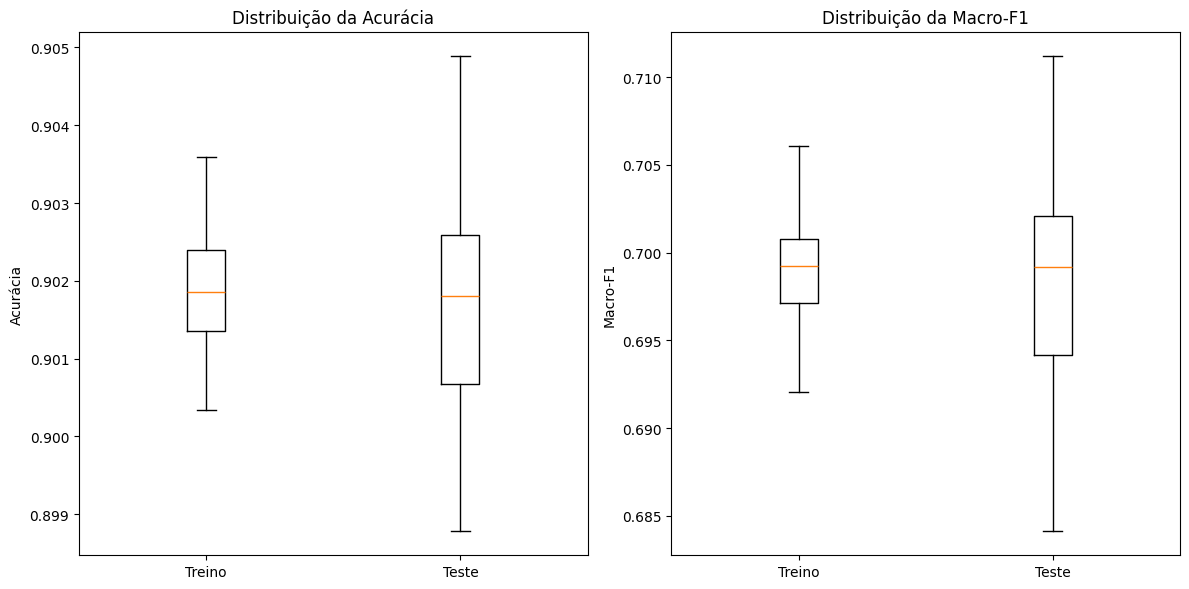

In [26]:
# Calcular média e desvio padrão das quatro distribuições

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Acurácia
plt.subplot(1, 2, 1)
plt.boxplot([resultados["acc_train"], resultados["acc_test"]], labels=["Treino", "Teste"])
plt.title("Distribuição da Acurácia")
plt.ylabel("Acurácia")

# Macro-F1
plt.subplot(1, 2, 2)
plt.boxplot([resultados["f1_train"], resultados["f1_test"]], labels=["Treino", "Teste"])
plt.title("Distribuição da Macro-F1")
plt.ylabel("Macro-F1")

plt.tight_layout()
plt.show()


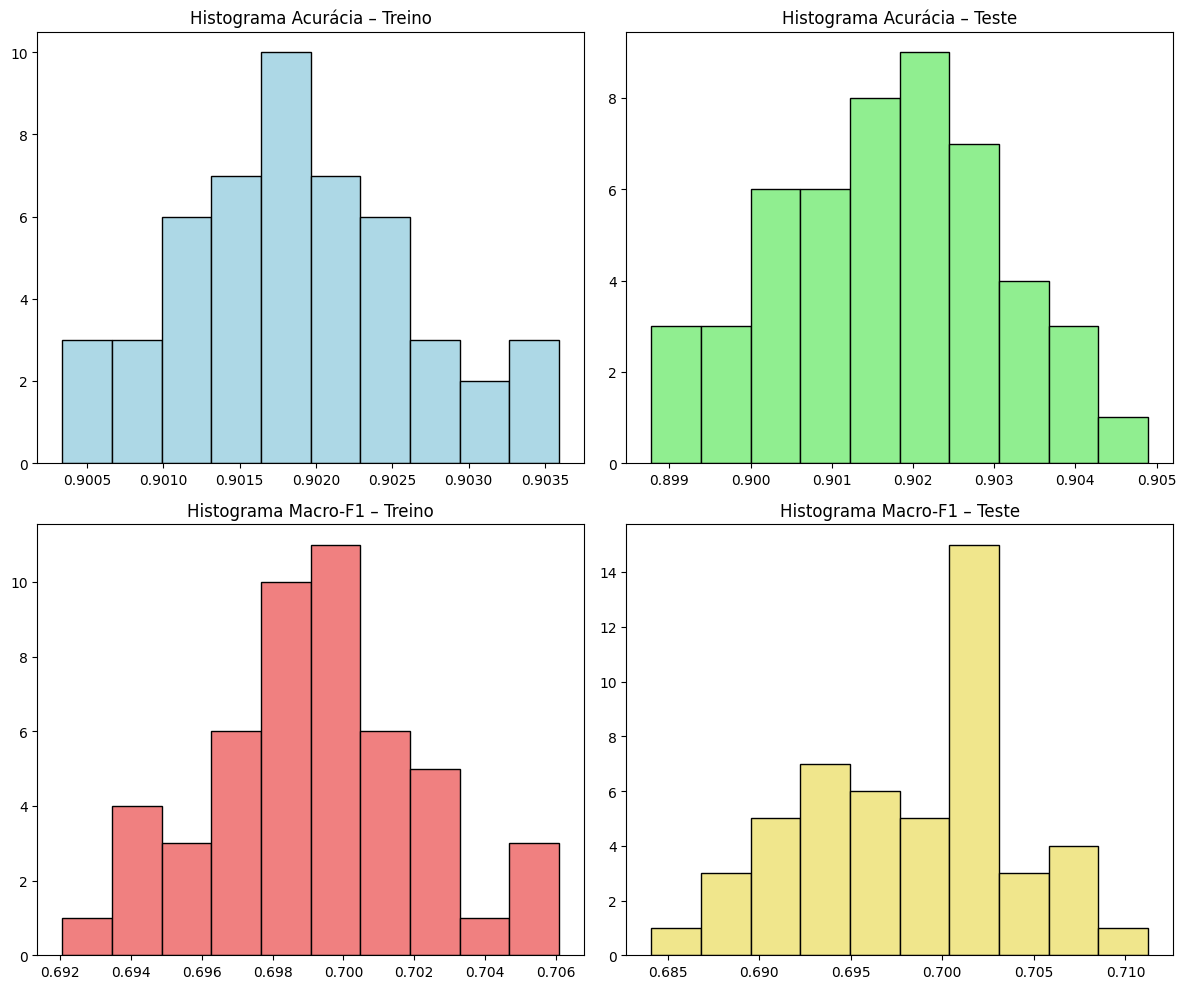

In [29]:
# histogramas das quatro distribuições

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(resultados["acc_train"], bins=10, color="lightblue", edgecolor="black")
plt.title("Histograma Acurácia – Treino")

plt.subplot(2, 2, 2)
plt.hist(resultados["acc_test"], bins=10, color="lightgreen", edgecolor="black")
plt.title("Histograma Acurácia – Teste")

plt.subplot(2, 2, 3)
plt.hist(resultados["f1_train"], bins=10, color="lightcoral", edgecolor="black")
plt.title("Histograma Macro-F1 – Treino")

plt.subplot(2, 2, 4)
plt.hist(resultados["f1_test"], bins=10, color="khaki", edgecolor="black")
plt.title("Histograma Macro-F1 – Teste")

plt.tight_layout()
plt.show()


### 4.1 Interpretação dos boxplots e histogramas

Os boxplots mostram que tanto a acurácia quanto a macro-F1 apresentam distribuições bastante concentradas, com pouca variabilidade entre as 50 repetições. Isso indica que a Regressão Logística é um modelo bastante estável para este conjunto de dados, mesmo com divisões aleatórias entre treino e teste.

A acurácia apresenta valores médios próximos de 0.902, tanto em treino quanto em teste. Isso reforça que o modelo generaliza bem: não há diferença significativa entre o desempenho em dados vistos e não vistos. Os intervalos interquartis também são estreitos, evidenciando baixa sensibilidade à aleatoriedade da partição.

No caso da macro-F1, observa-se que os valores estão concentrados entre aproximadamente 0.695 e 0.705, também com pequena variação. A macro-F1 é naturalmente inferior à acurácia, o que é esperado devido ao desbalanceamento da base (88 por cento classe “no” e 12 por cento classe “yes”). Ainda assim, a proximidade entre treino e teste demonstra que o modelo também generaliza bem quando avaliado de forma equilibrada entre as classes.

Os histogramas reforçam essas conclusões. Tanto para acurácia quanto para macro-F1, as distribuições são unimodais, simétricas e sem valores extremos. A concentração dos valores ao redor da média indica que o modelo apresenta alta estabilidade.

### 4.2 Comparação entre treino e teste

O comportamento visual e numérico demonstra que não há sinais de overfitting. As métricas de treino e teste são praticamente idênticas, tanto em média quanto em dispersão:

- Acurácia treino: média = 0.9019 | desvio = 0.00076  
- Acurácia teste : média = 0.9017 | desvio = 0.00139  

- Macro-F1 treino: média = 0.6992 | desvio = 0.00306  
- Macro-F1 teste : média = 0.6982 | desvio = 0.00571  

A diferença entre treino e teste é mínima, o que indica que o modelo não está se especializando no conjunto de treino. Além disso, o método de Repeated Holdout evidencia que a performance se mantém consistente ao longo das diferentes partições.

### 4.3 Comparação entre as métricas: Acurácia vs Macro-F1

As duas métricas não contam a mesma história:

- **Acurácia** privilegia a classe majoritária, por isso assume valores mais altos.  
- **Macro-F1** calcula a média das F1-scores das classes, penalizando desbalanceamentos.  

Como a classe “yes” representa apenas 12 por cento dos dados, a macro-F1 é mais adequada para medir a capacidade do modelo de detectar essa classe minoritária.

Ainda assim, a macro-F1 apresenta valores estáveis e próximos entre treino e teste, mostrando que o modelo não privilegia excessivamente apenas a classe “no”.

### 4.4 Conclusão geral

Os resultados mostram que:

- o método de Repeated Holdout foi bem-sucedido em estimar o desempenho esperado do modelo;
- o classificador apresentou **alta estabilidade**, com baixa variância das métricas;
- há **boa generalização**, pois treino e teste são muito próximos;
- a macro-F1 confirma o impacto do desbalanceamento, mas ainda assim mostra desempenho razoável;
- não há evidências de overfitting;
- o Pipeline evitou vazamento e garantiu um processo de modelagem consistente.



# Seção 5 – Conclusão Final do Projeto

Este projeto avaliou o desempenho esperado da Regressão Logística aplicada ao conjunto Bank Marketing por meio de 50 repetições do método Repeated Holdout. Os resultados mostraram que o modelo apresenta desempenho estável, com acurácia média de aproximadamente 0.902 e macro-F1 média próxima de 0.698, ambas com baixa variabilidade entre as repetições. A proximidade entre treino e teste indica ausência de overfitting e confirma que o pipeline de pré-processamento evitou vazamentos.

A comparação entre as métricas evidencia efeitos do desbalanceamento da base: a acurácia é elevada por refletir o domínio da classe majoritária, enquanto a macro-F1 fornece uma visão mais equilibrada do desempenho entre as classes e, por isso, assume valores menores. Ainda assim, a estabilidade da macro-F1 mostra que o modelo mantém desempenho consistente na classe minoritária.

Assim, a Regressão Logística demonstrou boa capacidade de generalização e comportamento robusto frente à aleatoriedade das partições, sendo adequada para este tipo de problema e bem alinhada aos objetivos definidos no início do estudo.
